In [1]:
import matplotlib.pyplot as plt
import matplotlib
#matplotlib.rcParams['text.latex.preamble']=[r"\usepackage{amsmath}"]

import pandas as pd
import numpy as np
from scipy import interpolate
from scipy.integrate import simpson
#%matplotlib qt
import os
cwd = '/home/lurishi/Escritorio/HeavenlyMCP/'
path_to_style=cwd+'/Figures'

custom_params = {
    'font.family': 'serif',
}

plt.rcParams.update(custom_params)

In [2]:
#--- Load the data
path=cwd+'/Data/MCP_flux/MCP_flux'
df_pi0_=pd.read_csv(r'/home/lurishi/Escritorio/HeavenlyMCP/Data/MCP_flux/MCP_FROM_PI0_SURFACE.csv' )
df_eta_=pd.read_csv(path+r'/MCP_FROM_ETA_SURFACE.csv' )
df_omega_=pd.read_csv(path+r'/MCP_FROM_OMEGA_SURFACE.csv' )
df_rho_=pd.read_csv(path+r'/MCP_FROM_RHO_SURFACE.csv'  )
df_phi_=pd.read_csv(path+r'/MCP_FROM_PHI_SURFACE.csv' )
df_jpsi_=pd.read_csv(path+r'/MCP_FROM_JPSI_SURFACE.csv'  )

In [3]:
df_pi0__ = df_pi0_[df_pi0_['cosTh'] == 1.0]
df_eta__ = df_eta_[df_eta_['cosTh'] == 1.0]
df_omega__ = df_omega_[df_omega_['cosTh'] == 1.0]
df_rho__ = df_rho_[df_rho_['cosTh'] == 1.0]
df_phi__ = df_phi_[df_phi_['cosTh'] == 1.0]
df_jpsi__ = df_jpsi_[df_jpsi_['cosTh'] == 1.0]

In [4]:
# Elegimos el mismo epsilon para todos los mesones padre

eps2 = 1e-4

df_pi0 = df_pi0__[df_pi0_['eps2'] == eps2]
df_eta = df_eta__[df_eta_['eps2'] == eps2]
df_omega = df_omega__[df_omega_['eps2'] == eps2]
df_rho = df_rho__[df_rho_['eps2'] == eps2]
df_phi = df_phi__[df_phi_['eps2'] == eps2]
df_jpsi = df_jpsi__[df_jpsi_['eps2'] == eps2]


/tmp/ipykernel_19167/1438996359.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_pi0 = df_pi0__[df_pi0_['eps2'] == eps2]
/tmp/ipykernel_19167/1438996359.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_eta = df_eta__[df_eta_['eps2'] == eps2]
/tmp/ipykernel_19167/1438996359.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_omega = df_omega__[df_omega_['eps2'] == eps2]
/tmp/ipykernel_19167/1438996359.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_rho = df_rho__[df_rho_['eps2'] == eps2]
/tmp/ipykernel_19167/1438996359.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_phi = df_phi__[df_phi_['eps2'] == eps2]
/tmp/ipykernel_19167/1438996359.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_jpsi = df_jpsi__[df_jpsi_['eps2'] == eps2]


In [5]:
df = [df_pi0, df_eta, df_omega, df_rho, df_phi, df_jpsi]
masses = [df_pi0['m(GeV)'].unique(), df_eta['m(GeV)'].unique(), df_omega['m(GeV)'].unique(), df_rho['m(GeV)'].unique(), df_phi['m(GeV)'].unique(), df_jpsi['m(GeV)'].unique()] # GeV
len(masses)

6

In [6]:
flujo_md = []
# Loopea sobre los mesones
for i in range(len(masses)):
    mass = masses[i]
    flux = np.zeros(len(mass))
    # Loopea sobre las masas
    for j in range(len(mass)):
        E = df[i]['Energy (GeV)'][df[i]['m(GeV)'] == mass[j]].values
        dif_flux = df[i]['dphi_dEdCth(1/GeV/s/cm2)'][df[i]['m(GeV)'] == mass[j]].values
        # Sort by energy to ensure correct integration sign
        order = np.argsort(E)
        E_sorted = E[order]
        dif_sorted = dif_flux[order]
        flux[j] = simpson(dif_sorted, E_sorted)/2*np.pi
    flujo_md.append(flux)

84


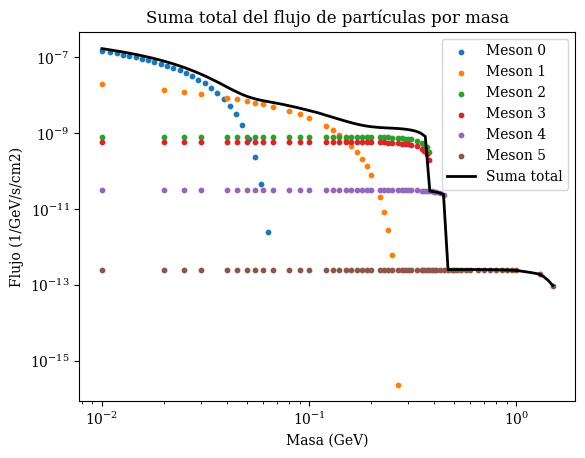

In [7]:
# Unir todas las listas/arrays de masas, convertirlas a arrays de NumPy y
# quedarnos con todos los valores únicos (ya ordenados).
common_mass_ = np.unique(np.concatenate([np.asarray(m) for m in masses]))

# Mostrar cuántos valores de masa únicos hay en total.
print(len(common_mass_))

# Crear una rejilla de 100 puntos espaciados logarítmicamente entre la
# masa mínima y la masa máxima encontradas.
common_mass = np.logspace(np.log10(common_mass_[0]), np.log10(common_mass_[-1]), 100)

# Lista donde se guardará el flujo interpolado de cada mesón sobre common_mass.
flujo_md_interp = []
for i in range(len(masses)):
    # Dibujar los puntos originales masa vs flujo de cada mesón.
    plt.scatter(masses[i], flujo_md[i], label=f'Meson {i}', s=10)

    # Ordenar las masas para poder interpolar correctamente.
    mass_sorted_idx = np.argsort(masses[i])
    mass_sorted = np.asarray(masses[i])[mass_sorted_idx]
    flux_sorted = np.asarray(flujo_md[i])[mass_sorted_idx]

    # Eliminar masas repetidas consecutivas, porque np.interp necesita x únicos.
    unique_mask = np.concatenate(([True], np.diff(mass_sorted) != 0))
    mass_unique = mass_sorted[unique_mask]
    flux_unique = flux_sorted[unique_mask]

    # Interpolar el flujo del mesón sobre la rejilla común.
    # Fuera del rango original, asignar cero.
    flujo_md_interp.append(
        np.interp(common_mass, mass_unique, flux_unique, left=0.0, right=0.0)
    )

# Sumar las contribuciones interpoladas de todos los mesones para obtener el flujo total.
flujo_total = np.sum(flujo_md_interp, axis=0)

# Dibujar el flujo total sobre la misma rejilla de masas.
plt.plot(common_mass, flujo_total, label='Suma total', color='black', linewidth=2)
plt.xlabel('Masa (GeV)')
plt.ylabel('Flujo (1/GeV/s/cm2)')
plt.title('Suma total del flujo de partículas por masa')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [8]:
df_lz = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Mcp_gráficos_papers/Flujo_MD_interpolado.csv')
df_lz_pi0 = pd.read_csv(
    '/home/lurishi/Escritorio/Doctorado/Mcp_gráficos_papers/Flujo_de_pi_0.csv',
    sep=';',
    header=None,
    names=['Masa[MeV/c2]', 'Flujo[s-1cm-2]'],
    decimal=','
)

In [9]:
print('df_lz columns:', df_lz.columns.tolist())
print('df_lz_pi0 columns:', df_lz_pi0.columns.tolist())

mass_col = 'Masa[MeV/c2]'
flux_col = 'Flujo[s-1cm-2]'

lz_sorted = df_lz.sort_values(mass_col)
pi0_sorted = df_lz_pi0.sort_values(mass_col)

# Usamos la malla de Lz y solo restamos pi0 donde ambos dominios se solapan
lz_mass = lz_sorted[mass_col].to_numpy()
lz_flux = lz_sorted[flux_col].to_numpy()

pi0_interp = np.interp(lz_mass, pi0_sorted[mass_col], pi0_sorted[flux_col]*2*np.pi, left=np.nan, right=np.nan)

overlap_mask = (
    (lz_mass >= lz_sorted[mass_col].min())
    & (lz_mass <= pi0_sorted[mass_col].max())
)

lz_diff = lz_flux.copy()
lz_diff[overlap_mask] = lz_flux[overlap_mask] - pi0_interp[overlap_mask]

print('lz size:', len(lz_mass))
print('overlap size:', overlap_mask.sum())
print('lz_diff head:', lz_diff[:5])

df_lz columns: ['Masa[MeV/c2]', 'Flujo[s-1cm-2]']
df_lz_pi0 columns: ['Masa[MeV/c2]', 'Flujo[s-1cm-2]']
lz size: 100
overlap size: 37
lz_diff head: [           nan 1.46954343e-08 1.42485031e-08 1.50699389e-08
 1.53805047e-08]


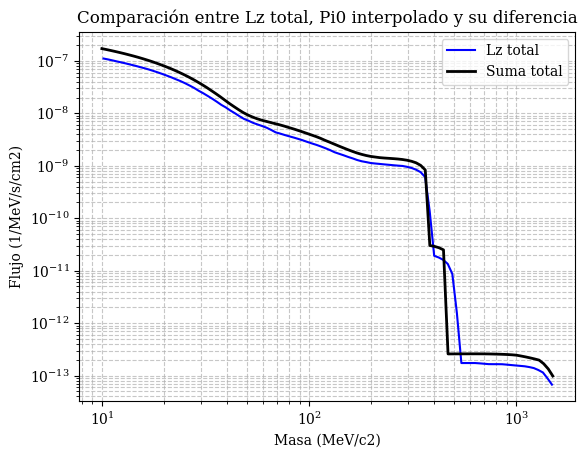

In [10]:
plt.plot(lz_mass, lz_flux, label='Lz total', color='blue')
#plt.plot(pi0_sorted[mass_col].to_numpy(), pi0_sorted[flux_col].to_numpy()*2*np.pi, label='Pi0 interpolado', color='orange')
plt.plot(common_mass*1000, flujo_total, label='Suma total', color='black', linewidth=2)
#plt.plot(lz_mass, lz_diff, label='Lz - Pi0', color='green')
plt.xlabel('Masa (MeV/c2)')
plt.ylabel('Flujo (1/MeV/s/cm2)')
plt.title('Comparación entre Lz total, Pi0 interpolado y su diferencia')
plt.xscale('log')
plt.yscale('log')
plt.grid(True,linestyle='--', which='both', alpha=0.7)
plt.legend()

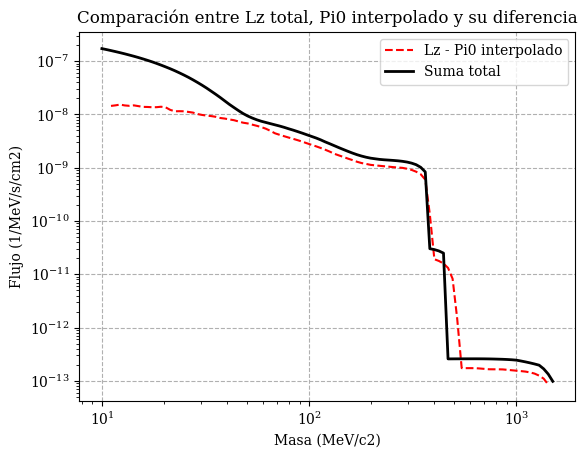

In [11]:
flujo_lz = np.interp(common_mass*1000, lz_mass, lz_diff, left=np.nan, right=np.nan)
plt.plot(common_mass*1000, flujo_lz, label='Lz - Pi0 interpolado', color='red', linestyle='--')
plt.plot(common_mass*1000, flujo_total, label='Suma total', color='black', linewidth=2) 
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Masa (MeV/c2)')
plt.ylabel('Flujo (1/MeV/s/cm2)')
plt.title('Comparación entre Lz total, Pi0 interpolado y su diferencia')
plt.xscale('log')
plt.yscale('log')
plt.grid(True,linestyle='--')
plt.legend()
plt.show()

In [12]:
flujo_lz/flujo_total

array([        nan,         nan,  0.09162093,  0.09820155,  0.10632611,
        0.10759141,  0.1113372 ,  0.11978323,  0.12257303,  0.1257612 ,
        0.13326552,  0.1406463 ,  0.15098601,  0.16566995,  0.1741305 ,
        0.16923126,  0.17300952,  0.19057071,  0.20863205,  0.22445854,
        0.24282194,  0.25543278,  0.27693779,  0.30436398,  0.3412728 ,
        0.37830717,  0.41370345,  0.46769347,  0.52239823,  0.5788457 ,
        0.62612745,  0.67283373,  0.72483238,  0.7507111 ,  0.77071217,
        0.77710812,  0.76300642,  0.73274489,  0.69381593,  0.68441011,
        0.68138892,  0.68411071,  0.68638571,  0.69006431,  0.69276789,
        0.69290045,  0.6945576 ,  0.69806083,  0.70332216,  0.71274952,
        0.71191438,  0.70549843,  0.71522095,  0.7248457 ,  0.7300552 ,
        0.73812472,  0.73661123,  0.73937311,  0.74846917,  0.74865223,
        0.75296372,  0.75845321,  0.75639474,  0.75268597,  0.74854996,
        0.74779471,  0.75370359,  0.7489305 ,  0.74660321,  0.73